In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

In [15]:
path = "cifar10/"

model_list = ["D4caddAPRD", "caddConvSE", "FlipConvFullWandD4caddAPRD", "caddD2ConvFWp6s2andD4caddAPRD", "caddAPRD"]
colour_list = ["purple", "green", "k", "blue", "orange"]


score_dictlist = [dict() for m in model_list]
final_pred_list = [dict() for m in model_list]
model_param_list = [dict() for m in model_list]

for i in range(len(model_list)):
    with np.load(path + model_list[i] + "/scores.npz") as data:
        score_dictlist[i]["model"] = model_list[i]
        score_dictlist[i]["step"] = data["step"]
        score_dictlist[i]["elapsed"] = data["elapsed"]
        score_dictlist[i]["elbo"] = -data["nelbo"]
        score_dictlist[i]["error"] = data["error"]
        score_dictlist[i]["nlpp"] = data["nlpp"]
        score_dictlist[i]["nlpp_miss"] = data["nlpp_miss"]
    with np.load(path + model_list[i] + "/final_predictions.npz") as data:
        final_pred_list[i]["model"] = model_list[i]
        final_pred_list[i]["final_pred"] = data["final_pred"]
        final_pred_list[i]["final_pred_correct"] = data["final_pred_correct"]
        final_pred_list[i]["final_pred_miss"] = data["final_pred_miss"]
        #final_pred_list[i]["correct_flag"] = data["correct_flag"]
    with np.load(path + model_list[i] + "/model.npz") as data:
        model_param_list[i]["model"] = model_list[i]
        for key, value in data.items():
            model_param_list[i][key] =data[key]

In [16]:
for i in range(len(model_list)):
    print(score_dictlist[i]["model"])
    print(colour_list[i])
    print()

D4caddAPRD
purple

caddConvSE
green

FlipConvFullWandD4caddAPRD
k

caddD2ConvFWp6s2andD4caddAPRD
blue

caddAPRD
orange



In [17]:
for i in range(len(model_list)):
    print(score_dictlist[i]["model"])
    print((score_dictlist[i]["elapsed"][-1])/1)
    print()

D4caddAPRD
125017.35516047478

caddConvSE
233671.00533795357

FlipConvFullWandD4caddAPRD
204892.64234876633

caddD2ConvFWp6s2andD4caddAPRD
206547.4928188324

caddAPRD
89364.32523083687



In [18]:
for i in range(len(model_list)):
    print(score_dictlist[i]["model"])
    print(score_dictlist[i]["elbo"][-1])
    print()

D4caddAPRD
-66662.25

caddConvSE
-49409.27

FlipConvFullWandD4caddAPRD
-43693.24

caddD2ConvFWp6s2andD4caddAPRD
-50991.297

caddAPRD
-72081.3



In [19]:
for i in range(len(model_list)):
    print(score_dictlist[i]["model"])
    print((1 - score_dictlist[i]["error"][-1])*100)
    print()

D4caddAPRD
57.24

caddConvSE
62.93

FlipConvFullWandD4caddAPRD
64.75

caddD2ConvFWp6s2andD4caddAPRD
65.24

caddAPRD
53.52



In [20]:
for i in range(len(model_list)):
    print(score_dictlist[i]["model"])
    print(np.round(score_dictlist[i]["error"][-1]*100,2))
    print()

D4caddAPRD
42.76

caddConvSE
37.07

FlipConvFullWandD4caddAPRD
35.25

caddD2ConvFWp6s2andD4caddAPRD
34.76

caddAPRD
46.48



In [21]:
for i in range(len(model_list)):
    print(score_dictlist[i]["model"])
    print(score_dictlist[i]["nlpp"][-1])
    print()

D4caddAPRD
12150.998

caddConvSE
10416.617

FlipConvFullWandD4caddAPRD
10163.805

caddD2ConvFWp6s2andD4caddAPRD
9980.772

caddAPRD
13260.167



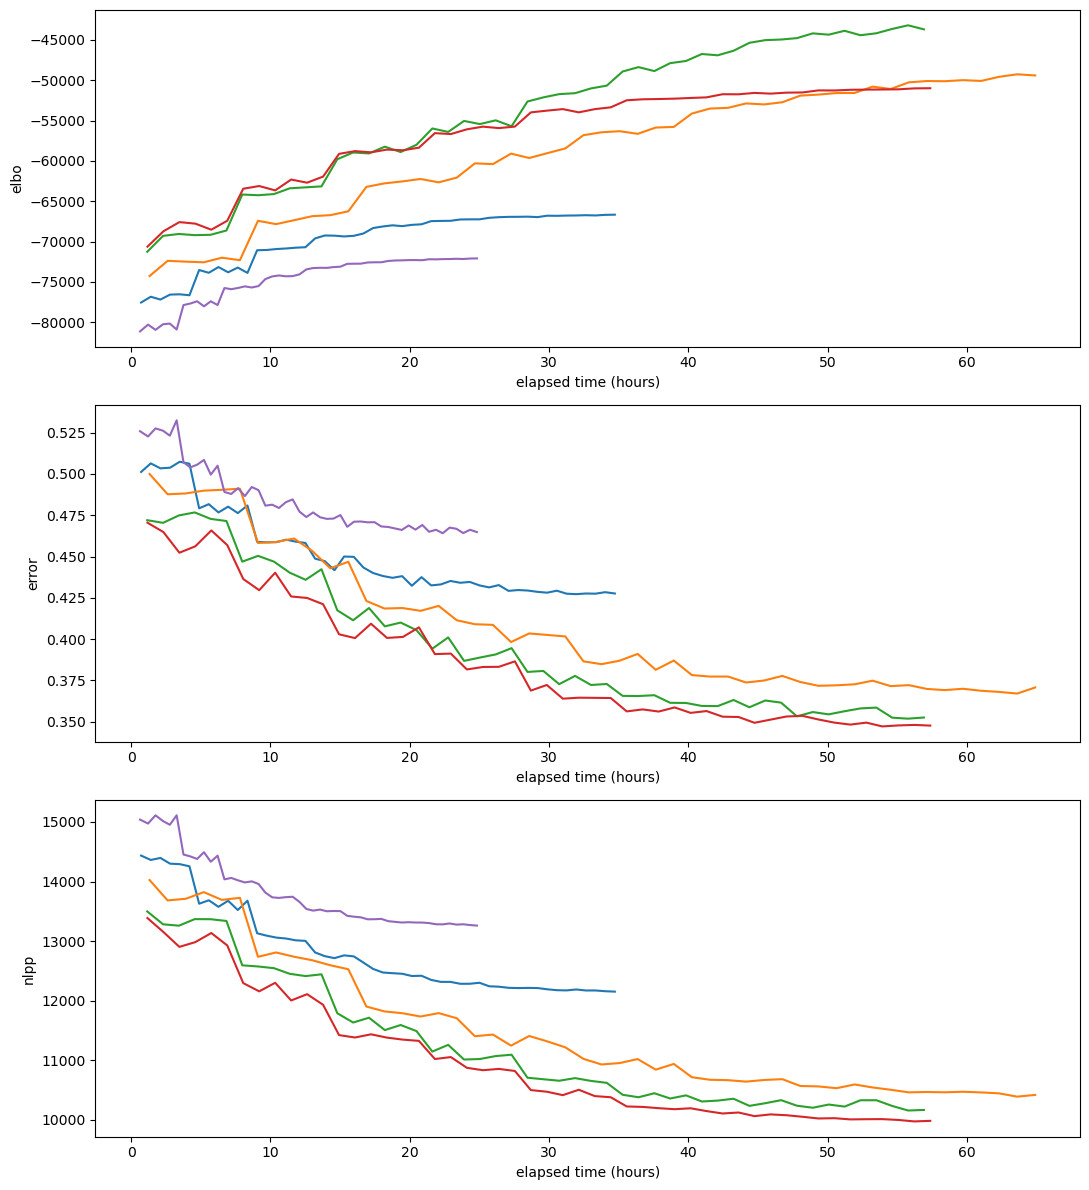

In [23]:
# Plot Scores with respect to runtime
# Just for illustration

fig = plt.figure(figsize=(11, 12))

ax1 = fig.add_subplot(3,1,1)
for i in range(len(model_list)):
    ax1.plot(score_dictlist[i]["elapsed"]/3600, score_dictlist[i]["elbo"])
ax1.set_xlabel("elapsed time (hours)")
ax1.set_ylabel("elbo")

ax2 = fig.add_subplot(3,1,2)
for i in range(len(model_list)):
    ax2.plot(score_dictlist[i]["elapsed"]/3600, score_dictlist[i]["error"])
ax2.set_xlabel("elapsed time (hours)")
ax2.set_ylabel("error")

ax3 = fig.add_subplot(3,1,3)
for i in range(len(model_list)):
    ax3.plot(score_dictlist[i]["elapsed"]/3600, score_dictlist[i]["nlpp"])
ax3.set_xlabel("elapsed time (hours)")
ax3.set_ylabel("nlpp")

fig.tight_layout()
plt.show()
plt.close()

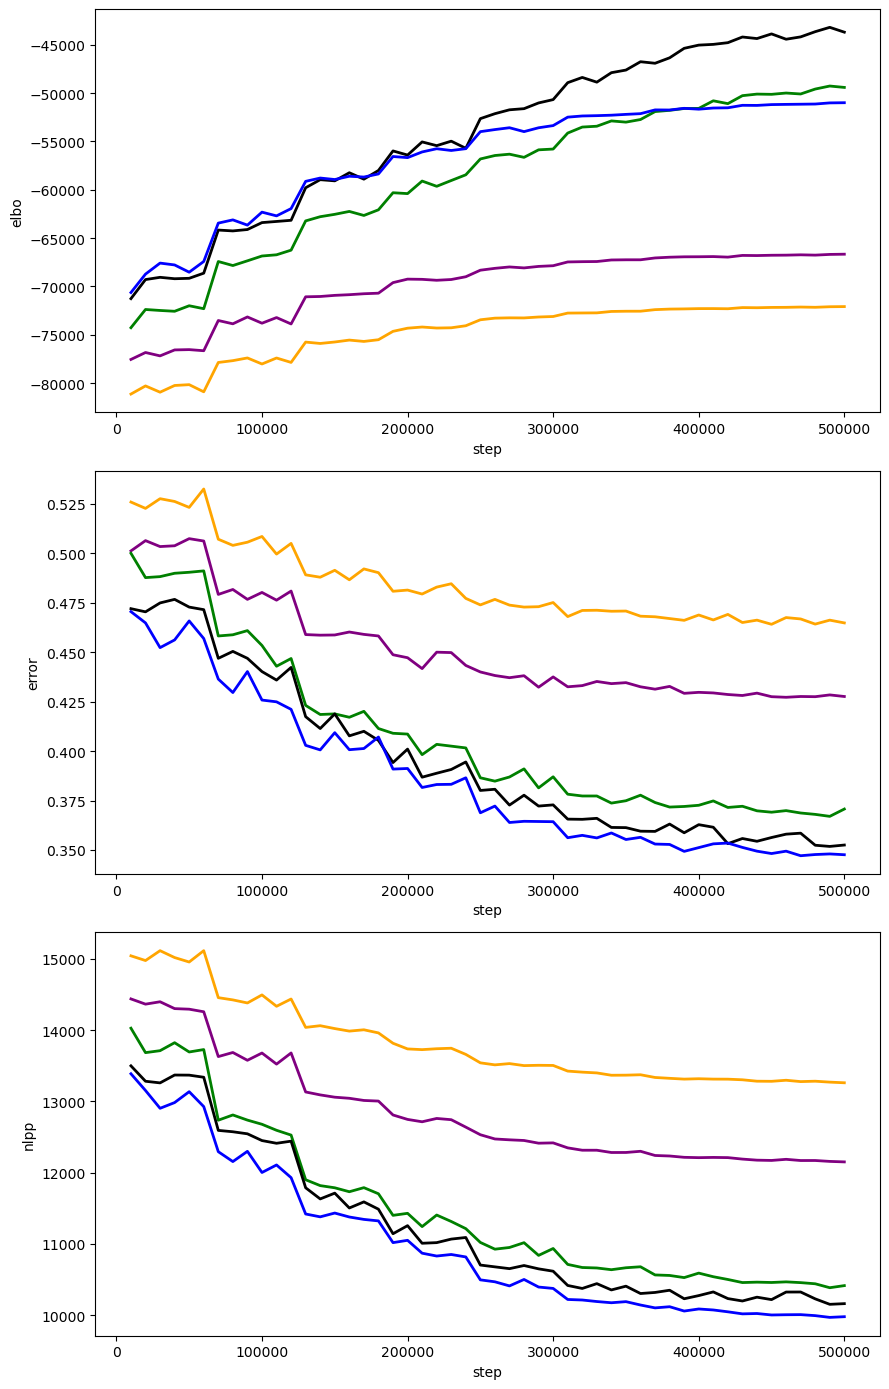

In [25]:
# Plot Scores with respect to training steps

fig = plt.figure(figsize=(9, 14))

ax1 = fig.add_subplot(3,1,1)
for i in range(len(model_list)):
    ax1.plot(score_dictlist[i]["step"], score_dictlist[i]["elbo"], label=score_dictlist[i]["model"], color=colour_list[i], linewidth=2.)
ax1.set_xlabel("step")
ax1.set_ylabel("elbo")
#ax1.set_ylim(bottom=-33000)#, top=np.max(error)+0.02)
#ax1.grid()
#ax1.set_xticks(range(0, 501000, 60000))

ax2 = fig.add_subplot(3,1,2)
for i in range(len(model_list)):
    ax2.plot(score_dictlist[i]["step"], score_dictlist[i]["error"], color=colour_list[i], linewidth=2.)
ax2.set_xlabel("step")
ax2.set_ylabel("error")
#ax2.set_ylim(top=0.10)
#ax2.grid()
#ax2.set_xticks(range(0, 501000, 60000))

ax3 = fig.add_subplot(3,1,3)
for i in range(len(model_list)):
    ax3.plot(score_dictlist[i]["step"], score_dictlist[i]["nlpp"], color=colour_list[i], linewidth=2.)
ax3.set_xlabel("step")
ax3.set_ylabel("nlpp")
#ax3.set_ylim(top=3400)
#ax3.grid()
#ax3.set_xticks(range(0, 501000, 60000))


fig.tight_layout()
#fig.legend()
plt.show()
plt.close()

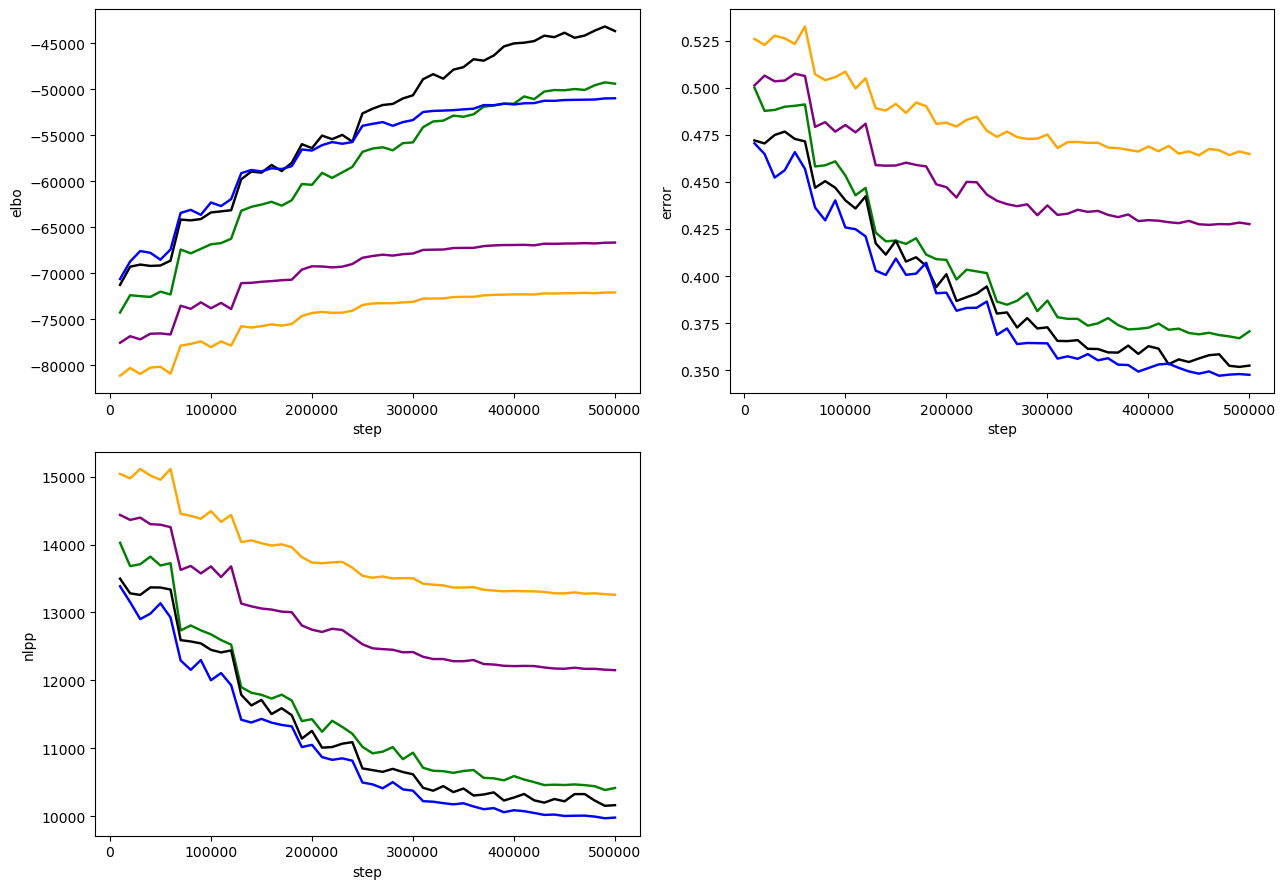

In [26]:
# Plot Scores with respect to training steps

fig = plt.figure(figsize=(13, 9))

ax1 = fig.add_subplot(2,2,1)
for i in range(len(model_list)):
    ax1.plot(score_dictlist[i]["step"], score_dictlist[i]["elbo"], label=score_dictlist[i]["model"], color=colour_list[i], linewidth=1.75)
ax1.set_xlabel("step")
ax1.set_ylabel("elbo")
#ax1.set_ylim(bottom=-33000)#, top=np.max(error)+0.02)
#ax1.grid()
#ax1.set_xticks(range(0, 501000, 60000))

ax2 = fig.add_subplot(2,2,2)
for i in range(len(model_list)):
    ax2.plot(score_dictlist[i]["step"], score_dictlist[i]["error"], color=colour_list[i], linewidth=1.75)
ax2.set_xlabel("step")
ax2.set_ylabel("error")
#ax2.set_ylim(top=0.10)
#ax2.grid()
#ax2.set_xticks(range(0, 501000, 60000))

ax3 = fig.add_subplot(2,2,3)
for i in range(len(model_list)):
    ax3.plot(score_dictlist[i]["step"], score_dictlist[i]["nlpp"], color=colour_list[i], linewidth=1.75)
ax3.set_xlabel("step")
ax3.set_ylabel("nlpp")
#ax3.set_ylim(top=3400)
#ax3.grid()
#ax3.set_xticks(range(0, 501000, 60000))


fig.tight_layout()
#fig.legend()
plt.show()
plt.close()